# A Neural Algorithm of Artistic Style

Replication of Gatys, Ecker and Bethge (2015), *A Neural Algorithm of Artistic Style*
(arXiv:1508.06576).

The paper shows that the content and the style of an image can be separated inside a
pretrained convolutional network: content is captured by deep feature activations, while
style is captured by the correlations between feature maps (Gram matrices) across several
layers. A new image is synthesized by gradient descent on the pixels to simultaneously match
one image's content features and another image's style Gram matrices. We implement this with
a pretrained VGG-19 and reproduce the effect: both losses fall and the output renders the
content scene in the texture and palette of the style image. The two source images are
generated procedurally so the notebook is fully self-contained.

In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.models import vgg19, VGG19_Weights
torch.manual_seed(0)
SIZE = 192

In [2]:
# Procedurally generate a content image (a simple landscape) and a swirling style image.
yy, xx = np.mgrid[0:SIZE, 0:SIZE] / SIZE
content = np.zeros((SIZE, SIZE, 3), np.float32)
content[..., 2] = 0.5 + 0.4*(1-yy)                       # blue sky gradient
content[..., 0] = 0.3 + 0.3*(1-yy)
sun = ((xx-0.75)**2 + (yy-0.25)**2) < 0.02
content[sun] = [1.0, 0.9, 0.2]                           # sun
ground = yy > 0.7
content[ground] = [0.2, 0.6, 0.25]                       # green ground
house = (np.abs(xx-0.4) < 0.12) & (yy > 0.55) & (yy < 0.72)
content[house] = [0.7, 0.35, 0.25]                       # house body
roof = (yy > 0.47) & (yy < 0.56) & (np.abs(xx-0.4) < (yy-0.47)*1.2)
content[roof] = [0.45, 0.2, 0.15]

r = np.sqrt((xx-0.5)**2 + (yy-0.5)**2)
style = np.stack([
    0.5 + 0.5*np.sin(30*r + 8*xx),
    0.4 + 0.4*np.sin(24*r + 6*yy + 1.5),
    0.6 + 0.4*np.cos(18*xx*yy*12)], -1).astype(np.float32)  # swirling brush-like texture
style = np.clip(style, 0, 1)
print("content", content.shape, "style", style.shape)

content (192, 192, 3) style (192, 192, 3)


In [3]:
norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
to_t = lambda a: norm(torch.tensor(a).permute(2, 0, 1)).unsqueeze(0).float()
content_t, style_t = to_t(content), to_t(style)

vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.eval()
for p in vgg.parameters(): p.requires_grad_(False)
content_layers = {21}                                    # conv4_2
style_layers   = {0, 5, 10, 19, 28}                      # conv1_1 .. conv5_1
def features(x):
    feats = {}
    for i, layer in enumerate(vgg):
        x = layer(x)
        if i in content_layers or i in style_layers: feats[i] = x
    return feats

def gram(f):
    b, c, h, w = f.shape
    f = f.view(c, h*w)
    return (f @ f.t()) / (c*h*w)
print("VGG-19 feature extractor ready")

VGG-19 feature extractor ready


In [4]:
c_targets = {i: features(content_t)[i].detach() for i in content_layers}
s_targets = {i: gram(features(style_t)[i]).detach() for i in style_layers}

img = content_t.clone().requires_grad_(True)             # initialize from content image
opt = torch.optim.Adam([img], lr=0.05)
mse = nn.MSELoss()
hist_c, hist_s = [], []
for step in range(300):
    opt.zero_grad()
    f = features(img)
    c_loss = sum(mse(f[i], c_targets[i]) for i in content_layers)
    s_loss = sum(mse(gram(f[i]), s_targets[i]) for i in style_layers)
    loss = c_loss + 1e5 * s_loss                         # style weighted higher
    loss.backward(); opt.step()
    hist_c.append(c_loss.item()); hist_s.append(s_loss.item())
    if (step+1) % 60 == 0:
        print(f"step {step+1}: content={c_loss.item():.3f}  style={s_loss.item():.5f}")

step 60: content=20.908  style=0.00107


step 120: content=21.751  style=0.00045


step 180: content=21.447  style=0.00029


step 240: content=20.992  style=0.00022


step 300: content=20.564  style=0.00019


In [5]:
print(f"content loss: {hist_c[0]:.3f} -> {hist_c[-1]:.3f}")
print(f"style loss  : {hist_s[0]:.5f} -> {hist_s[-1]:.5f}")

content loss: 0.000 -> 20.564
style loss  : 0.00917 -> 0.00019


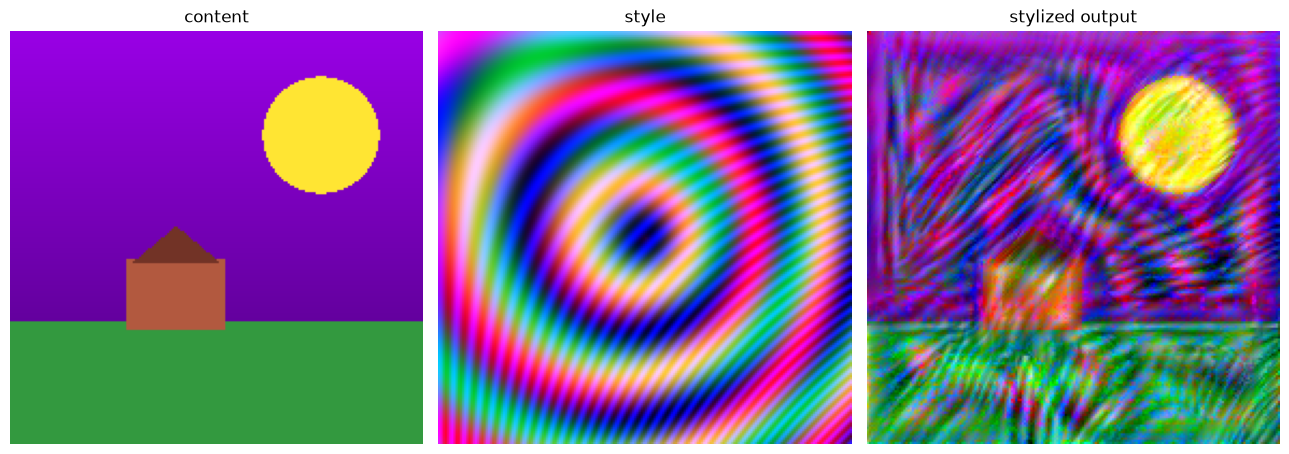

In [6]:
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1); std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
show = lambda t: (t.detach()[0]*std + mean).clamp(0,1).permute(1,2,0).numpy()
fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
for A, im, ttl in [(ax[0], content, "content"), (ax[1], style, "style"), (ax[2], show(img), "stylized output")]:
    A.imshow(im); A.set_title(ttl); A.axis("off")
plt.tight_layout(); plt.show()